# 05 — Módulo 3: Treinamento do Modelo (Random Forest)

Este notebook recebe o vetor numérico gerado no Módulo 2 e treina um modelo de Machine Learning (`RandomForestClassifier`) para tomar decisões de jogo.

**Objetivo:**
Com base no estado das 15 bolas (ordenadas por distância até a branca), o modelo deve classificar **qual é o índice da melhor bola (de 1 a 15)** para realizar a jogada.

**Como funciona:**
1. **Auto-Labeling:** Caso o dataset não tenha a "resposta certa" (label) anotada manualmente, o script gera uma classificação automática priorizando bolas com menor **ângulo de corte**.
2. **Treino e Teste:** Divide os dados (80% para treino, 20% para teste).
3. **Random Forest:** Aprende os padrões não-lineares (ex: "Se o ângulo de corte for menor que X e a distância menor que Y, escolha esta bola").
4. **Exportação:** Salva o "cérebro" do modelo em `models/modelo.pkl` para ser usado em tempo real depois.

In [22]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import matplotlib.pyplot as plt

## 1. Carregar os Dados e Criar Labels (Respostas)

Como estamos carregando o `dataset.csv` gerado no Módulo 2, ele possui apenas as "Features" (as colunas `X`). Para treinar um modelo supervisionado, precisamos do `y` (a resposta correta).
O código abaixo implementa uma heurística rápida: ele varre a linha e elege como **Bola Alvo** aquela que tem o menor **ângulo de corte** (tiro mais reto) e que não é uma caçapa preenchida com zeros.

In [23]:
# Caminho para os dados (considerando que o notebook está em /modulo3 ou na raiz)
CAMINHO_CSV = os.path.join('..', 'data', 'dataset.csv')
CAMINHO_MODELOS = os.path.join('..', 'models')

os.makedirs(CAMINHO_MODELOS, exist_ok=True)

try:
    df = pd.read_csv(CAMINHO_CSV)
    print(f"Dataset carregado! {df.shape[0]} linhas (frames) e {df.shape[1]} colunas.")
except FileNotFoundError:
    print(f"Erro: Arquivo {CAMINHO_CSV} não encontrado. Rode o Módulo 2 primeiro.")
    df = None

if df is not None:
    # SE NÃO EXISTIR A COLUNA DE RESPOSTA, VAMOS CRIAR COM AS REGRAS DO JOGO
    if 'alvo_bola' not in df.columns:
        print("Gerando labels automaticamente com regras de grupo...")
        labels = []
        
        # === DEFINA SEU GRUPO AQUI ===
        # 1.0 = Lisas | -1.0 = Listradas
        MEU_GRUPO = 1.0 
        
        for index, row in df.iterrows():
            melhor_bola_idx = None
            menor_dificuldade = float('inf')
            
            for i in range(1, 16):
                tipo = row[f'b{i}_tipo']
                ang_corte = row[f'b{i}_ang_corte']
                dist_cacapa = row[f'b{i}_dist_cacapa']
                
                # 1. Ignora posições vazias (zero-padding)
                if ang_corte == 0.0 and dist_cacapa == 0.0 and tipo == 0.0:
                    continue
                    
                # 2. A REGRA DE OURO: Ignora as bolas do inimigo!
                if tipo != MEU_GRUPO:
                    continue
                
                # 3. Calcula a dificuldade APENAS para as suas bolas
                dificuldade = ang_corte + (dist_cacapa * 0.5)
                
                if dificuldade < menor_dificuldade:
                    menor_dificuldade = dificuldade
                    melhor_bola_idx = i
                    
            # Se não achou nenhuma bola do seu grupo (ex: só sobrou a 8), chuta a bola 1 provisoriamente
            if melhor_bola_idx is None:
                melhor_bola_idx = 1
                
            labels.append(melhor_bola_idx)
            
        df['alvo_bola'] = labels
        print(f"Labels criados! O modelo agora sabe que deve caçar apenas bolas do tipo {MEU_GRUPO}.")

Dataset carregado! 6 linhas (frames) e 107 colunas.
Gerando labels automaticamente com regras de grupo...
Labels criados! O modelo agora sabe que deve caçar apenas bolas do tipo 1.0.


/tmp/ipykernel_115509/2099738074.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['alvo_bola'] = labels


## 2. Treinamento do Random Forest

Agora dividimos os dados entre Matriz de Features (`X`) e Vetor Target (`y`).
Utilizamos 100 árvores de decisão (`n_estimators=100`) para compor a nossa "Floresta".

In [24]:
if df is not None:
    # X contém todas as colunas de dados geométricos, exceto o label que acabamos de criar
    X = df.drop(columns=['alvo_bola'])
    
    # y é a resposta que o modelo tem que tentar adivinhar
    y = df['alvo_bola']
    
    # Como você deve ter poucas imagens no início, vamos usar um split seguro (pode dar erro se houver apenas 1 linha)
    if len(df) > 5:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    else:
        print("Aviso: Você tem pouquíssimos dados. O modelo vai treinar e testar nos mesmos dados apenas por enquanto.")
        X_train, X_test, y_train, y_test = X, X, y, y
        
    print(f"Treinando com {len(X_train)} amostras...")

    # Instancia e Treina o Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        random_state=42,
        class_weight='balanced' # Ajuda se algumas bolas forem escolhidas com muito mais frequência
    )
    
    rf_model.fit(X_train, y_train)
    
    # Previsões para avaliar a precisão
    y_pred = rf_model.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    
    print(f"Treinamento concluído! Acurácia no Teste: {acuracia * 100:.2f}%")

Treinando com 4 amostras...
Treinamento concluído! Acurácia no Teste: 50.00%


## 3. Avaliação de Importância (Feature Importance) e Exportação

Uma das grandes vantagens do Random Forest é que ele nos diz quais informações ele usou para tomar as decisões. Vamos plotar as variáveis mais importantes e, por fim, exportar o cérebro treinado em `.pkl`.

Top 10 Características mais importantes para o modelo:
        Feature  Importância
  b1_ang_branca     0.053191
  b11_ang_corte     0.042553
           b1_x     0.031915
  b5_ang_branca     0.031915
b13_dist_branca     0.031915
   b9_ang_corte     0.031915
           b1_y     0.031915
  b13_ang_corte     0.031915
   b3_ang_corte     0.021277
 b3_dist_branca     0.021277


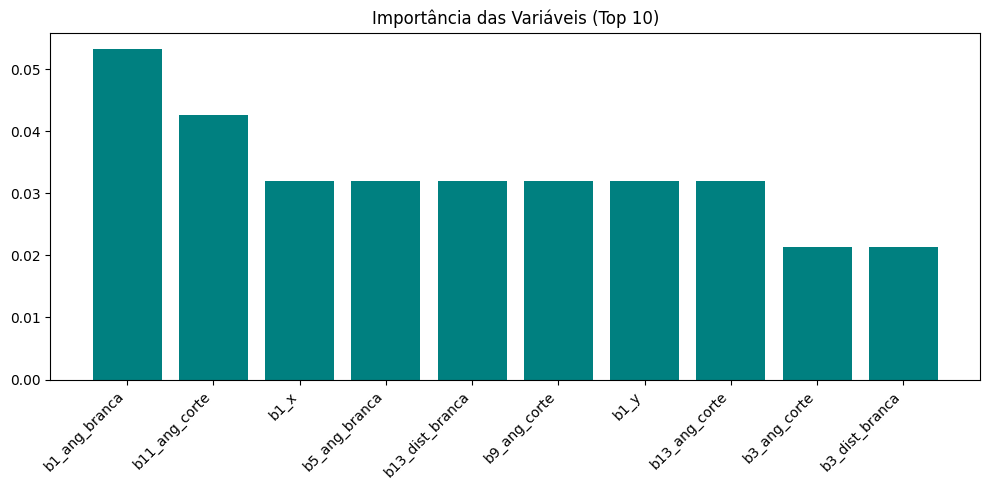

Modelo salvo com sucesso em: ../models/modelo.pkl
Agora você pode carregar este arquivo .pkl na sua aplicação em tempo real!


In [25]:
if df is not None:
    # Pega a importância de cada coluna
    importancias = rf_model.feature_importances_
    colunas = X.columns
    
    # Organiza em um DataFrame para visualização
    df_imp = pd.DataFrame({
        'Feature': colunas,
        'Importância': importancias
    }).sort_values(by='Importância', ascending=False)
    
    # Mostra as 10 características que o robô mais olhou para decidir a jogada
    print("Top 10 Características mais importantes para o modelo:")
    print(df_imp.head(10).to_string(index=False))
    
    # Plotagem simples
    plt.figure(figsize=(10, 5))
    plt.bar(df_imp['Feature'].head(10), df_imp['Importância'].head(10), color='teal')
    plt.xticks(rotation=45, ha='right')
    plt.title('Importância das Variáveis (Top 10)')
    plt.tight_layout()
    plt.show()

    # SALVAR O MODELO
    caminho_pkl = os.path.join(CAMINHO_MODELOS, 'modelo.pkl')
    joblib.dump(rf_model, caminho_pkl)
    
    print(f"Modelo salvo com sucesso em: {caminho_pkl}")
    print("Agora você pode carregar este arquivo .pkl na sua aplicação em tempo real!")

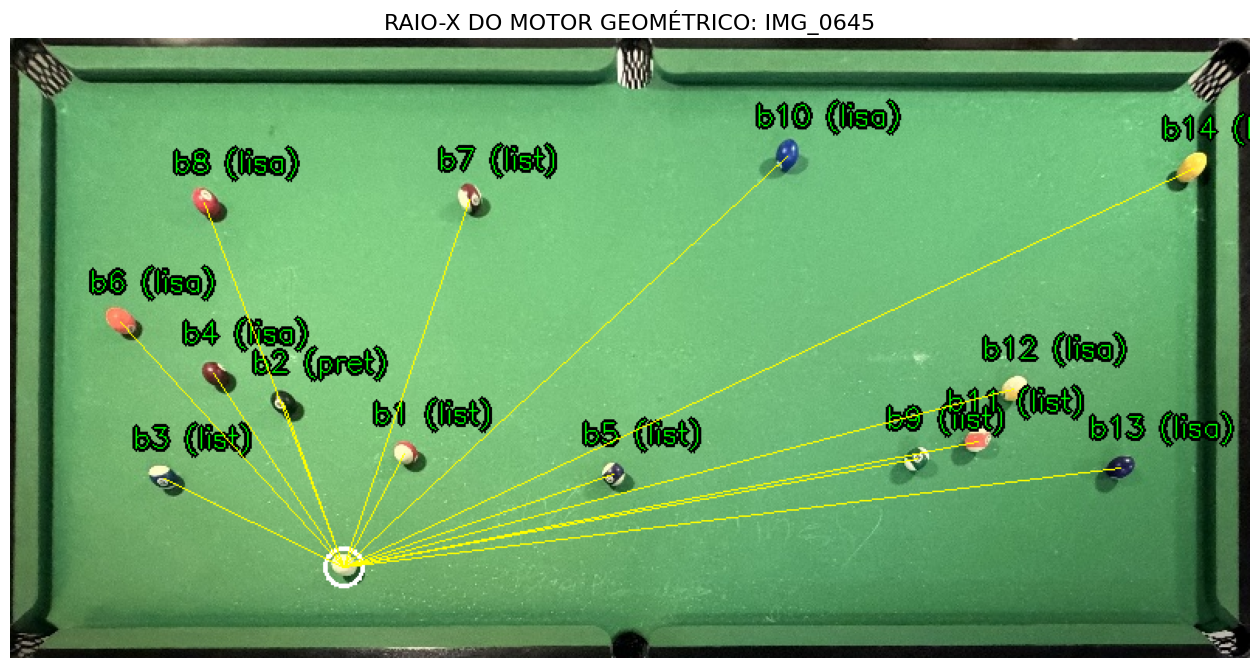

In [26]:
# ============================================================
# Célula de Depuração Visual: O que o Módulo 4 está a ver?
# ============================================================
import os
import cv2
import json
import math
import matplotlib.pyplot as plt

# --- 1. Escolha a imagem que quer auditar ---
NOME_IMAGEM = "IMG_0645" # Troque para o nome da imagem que quer testar

# O uso de '../' faz o código sair da pasta 'modulo3' e ir para a raiz do projeto
CAMINHO_IMG = f"../data/normalized/{NOME_IMAGEM}.JPG" 
CAMINHO_JSON = f"../data/output/{NOME_IMAGEM}_balls.json"

# Carrega os dados
imagem = cv2.imread(CAMINHO_IMG)

# Verifica se a imagem foi carregada corretamente
if imagem is None:
    # Tenta carregar com .jpg minúsculo caso o .JPG maiúsculo falhe
    CAMINHO_IMG = f"../data/normalized/{NOME_IMAGEM}.jpg"
    imagem = cv2.imread(CAMINHO_IMG)
    if imagem is None:
        print(f"Erro: Não foi possível encontrar a imagem em {CAMINHO_IMG}")

if imagem is not None:
    try:
        with open(CAMINHO_JSON, 'r', encoding='utf-8') as f:
            dados = json.load(f)

        # Encontra a bola branca
        branca = next((b for b in dados['bolas'] if b['tipo'] == 'branca'), None)
        outras_bolas = [b for b in dados['bolas'] if b['tipo'] != 'branca']

        if branca is None:
            print("Erro: Nenhuma bola branca encontrada neste JSON.")
        else:
            # --- 2. Recria a ordenação do Módulo 4 (Ex: por distância à branca) ---
            def calc_dist(b1, b2):
                return math.hypot(b1['x'] - b2['x'], b1['y'] - b2['y'])
            
            # Ordena as outras bolas para descobrir quem é a b1, b2, b3...
            outras_bolas.sort(key=lambda b: calc_dist(branca, b))

            imagem_debug = imagem.copy()
            
            # Desenha a branca
            cv2.circle(imagem_debug, (branca['x'], branca['y']), 12, (255, 255, 255), 2)

            # --- 3. Desenha os Labels (b1, b2...) e Linhas de Tiro ---
            for i, bola in enumerate(outras_bolas):
                nome_variavel = f"b{i+1}"
                cx, cy = bola['x'], bola['y']
                
                # Desenha a linha da branca até a bola alvo (simulando a mira)
                cv2.line(imagem_debug, (branca['x'], branca['y']), (cx, cy), (0, 255, 255), 1)
                
                # Etiqueta preta com o texto verde brilhante para alto contraste
                texto = f"{nome_variavel} ({bola['tipo'][:4]})"
                cv2.putText(imagem_debug, texto, (cx - 20, cy - 20), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3) # Borda preta
                cv2.putText(imagem_debug, texto, (cx - 20, cy - 20), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1) # Texto verde

            # --- 4. Exibe o Raio-X ---
            plt.figure(figsize=(16, 10))
            plt.imshow(cv2.cvtColor(imagem_debug, cv2.COLOR_BGR2RGB))
            plt.title(f"RAIO-X DO MOTOR GEOMÉTRICO: {NOME_IMAGEM}", fontsize=16)
            plt.axis('off')
            plt.show()

    except FileNotFoundError:
        print(f"Erro: O arquivo JSON não foi encontrado no caminho: {CAMINHO_JSON}")